# 01 · Exploratory data analysis
US DOT BTS Reporting Carrier On-Time Performance, Aug 2025 – Jul 2026, loaded by `flightops.ingest` and cleaned by `sql/staging`. Questions: how big is the problem, when and where does it happen, and what causes it?

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import duckdb, pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
con = duckdb.connect(str(ROOT / "data/warehouse/flightops.duckdb"), read_only=True)
q = lambda s: con.execute(s).df()

In [2]:
q('SELECT * FROM marts.kpi_overview').T

,0
first_date,2025-08-01 00:00:00
last_date,2026-07-31 00:00:00
scheduled_flights,7043842
completed_flights,6895508.0
carriers,14
origin_airports,359
routes,7162
on_time_pct,77.63
avg_arr_delay_min,8.11
avg_delay_when_late_min,72.51


## Volume and punctuality by month

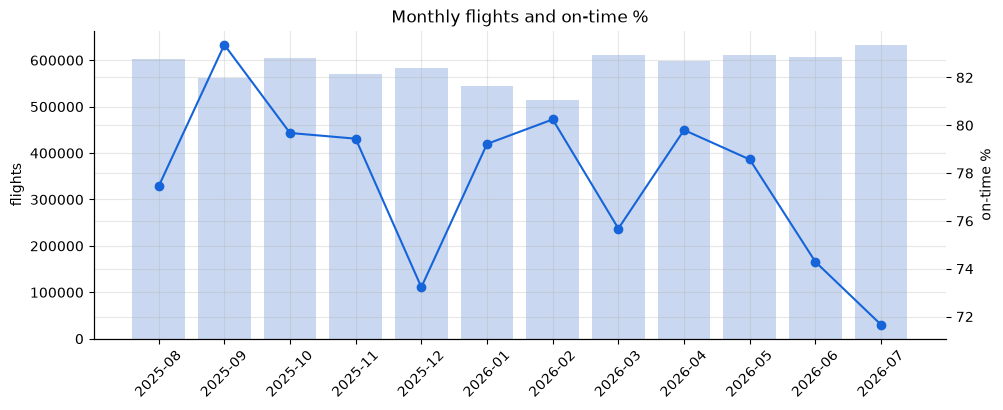

,year_month,flights,otp,canc
0,2025-08,602378,77.444407,1.076235
1,2025-09,562439,83.368408,0.513122
2,2025-10,605844,79.678009,0.528849
3,2025-11,570546,79.439937,2.487968
4,2025-12,582303,73.228436,1.545587
5,2026-01,543999,79.220721,4.712325
6,2026-02,515036,80.244469,2.253046
7,2026-03,612098,75.680914,2.902476
8,2026-04,597918,79.801118,0.903301
9,2026-05,611735,78.570058,0.924420


In [3]:
m = q('''SELECT year_month, count(*) flights, 100*(1-avg(arr_del15)) otp, 100*avg(cancelled) canc
          FROM staging.stg_flights GROUP BY 1 ORDER BY 1''')
fig, ax = plt.subplots(); ax.bar(m.year_month, m.flights, color='#C9D8F0'); ax2 = ax.twinx()
ax2.plot(m.year_month, m.otp, 'o-', color='#1664D9'); ax2.set_ylabel('on-time %'); ax.set_ylabel('flights')
plt.setp(ax.get_xticklabels(), rotation=45); plt.title('Monthly flights and on-time %'); plt.show(); m

December 2025 and July 2026 are the weakest months; test months (Jun–Jul 2026) are clearly worse than most training months - relevant for model evaluation.

## Carriers

In [4]:
c = q('''SELECT c.carrier_name, count(*) flights, round(100*(1-avg(arr_del15)),1) otp,
                 round(avg(arr_delay_min) FILTER (WHERE completed=1),1) avg_delay,
                 round(100*avg(cancelled),2) cancel_pct, min(flight_date) first_day, max(flight_date) last_day
          FROM staging.stg_flights f JOIN staging.stg_carriers c ON c.carrier_code=f.carrier
          GROUP BY 1 ORDER BY otp DESC''')
c

,carrier_name,flights,otp,avg_delay,cancel_pct,first_day,last_day
0,Hawaiian Airlines Inc.,33121,81.9,7.6,0.74,2025-08-01,2025-12-31
1,Delta Air Lines Inc.,1038644,81.5,3.9,1.71,2025-08-01,2026-07-31
2,Envoy Air,317726,80.9,4.2,2.22,2025-08-01,2026-07-31
3,Alaska Airlines Inc.,301435,79.6,2.9,1.16,2025-08-01,2026-07-31
4,United Air Lines Inc.,825693,79.3,6.3,1.03,2025-08-01,2026-07-31
5,SkyWest Airlines Inc.,854128,79.0,9.6,1.78,2025-08-01,2026-07-31
6,Republic Airline,363167,78.7,5.3,4.13,2025-08-01,2026-07-31
7,Southwest Airlines Co.,1389938,76.4,6.8,0.88,2025-08-01,2026-07-31
8,American Airlines Inc.,987645,74.6,13.3,2.20,2025-08-01,2026-07-31
9,PSA Airlines Inc.,242215,74.1,15.1,4.29,2025-08-01,2026-07-31


Hawaiian Airlines reports only through 2025-12-31 and Spirit through 2026-05-01 in this window, so carrier trends for those two are partial.

## Time of day - delays build up through the day

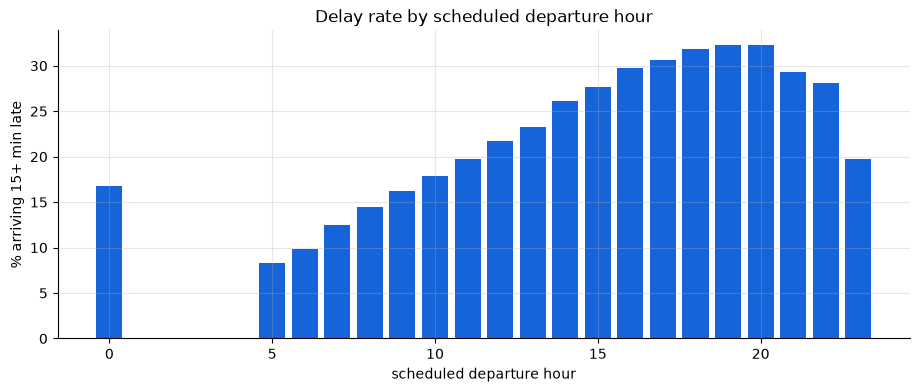

In [5]:
h = q('''SELECT dep_hour, count(*) n, 100*avg(arr_del15) delay_rate, 100*avg(cancelled) cancel_rate
          FROM staging.stg_flights GROUP BY 1 ORDER BY 1''')
h = h[h.n > 5000]
plt.bar(h.dep_hour, h.delay_rate, color='#1664D9'); plt.xlabel('scheduled departure hour'); plt.ylabel('% arriving 15+ min late')
plt.title('Delay rate by scheduled departure hour'); plt.show()

## Delay-cause mix

In [6]:
cz = q('''SELECT sum(carrier_delay_min) carrier, sum(weather_delay_min) weather, sum(nas_delay_min) nas,
                  sum(security_delay_min) AS security_min, sum(late_aircraft_delay_min) late_aircraft FROM staging.stg_flights''').T
cz.columns = ['minutes']; cz['share_%'] = (100 * cz.minutes / cz.minutes.sum()).round(2); cz

,minutes,share_%
carrier,37248443.0,33.31
weather,6837243.0,6.11
nas,23133857.0,20.69
security_min,161776.0,0.14
late_aircraft,44441449.0,39.74


Late-arriving aircraft (knock-on) and carrier causes dominate; weather coded as 'extreme weather' is a small share (weather also hides inside NAS delays).

## Distribution of arrival delay (heavy tail)

count    293629.0
mean          8.1
std          60.7
min         -87.0
10%         -24.0
25%         -16.0
50%          -6.0
75%          11.0
90%          48.0
95%          88.0
99%         226.0
max        2526.0
Name: arr_delay_min, dtype: float64


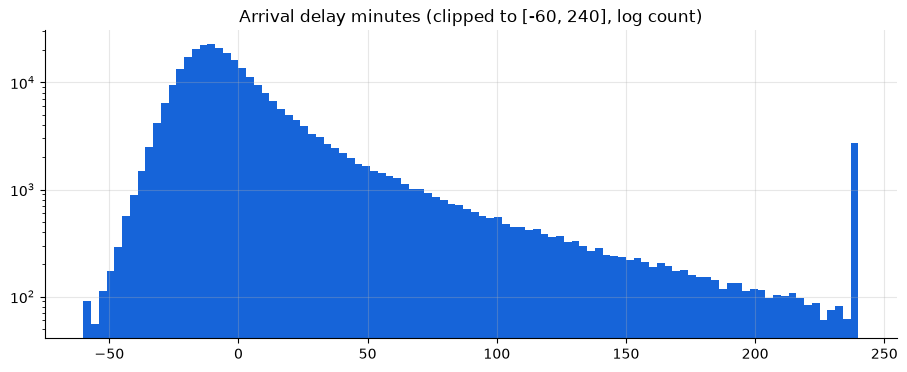

In [7]:
d = q('SELECT arr_delay_min FROM staging.stg_flights WHERE completed=1 USING SAMPLE 300000 ROWS')
print(d.arr_delay_min.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(1))
plt.hist(d.arr_delay_min.clip(-60, 240), bins=100, color='#1664D9'); plt.yscale('log')
plt.title('Arrival delay minutes (clipped to [-60, 240], log count)'); plt.show()

Median flight arrives early, the mean is pulled up by a long tail - this is why the regression model reports MAE and quantiles rather than chasing RMSE.

## Busiest airports and worst routes

In [8]:
q('SELECT * FROM marts.kpi_airport_month').groupby('airport_code').scheduled_departures.sum().nlargest(10)

airport_code
ORD    359911
DEN    319207
ATL    315859
DFW    312515
PHX    197641
LAX    190106
CLT    181506
LAS    172930
SEA    164821
MCO    160601
Name: scheduled_departures, dtype: int64

In [9]:
q('SELECT * FROM marts.kpi_route ORDER BY on_time_pct LIMIT 10')

,route,origin,dest,distance_mi,scheduled_flights,carriers,on_time_pct,avg_arr_delay_min,p90_arr_delay_min,cancellation_rate_pct
0,MDW-SFO,MDW,SFO,1855.0,485,1,48.12,26.76,75.0,1.237
1,SYR-FLL,SYR,FLL,1197.0,300,2,49.48,43.78,115.0,2.667
2,DFW-BFL,DFW,BFL,1271.0,311,1,53.38,59.03,144.5,3.859
3,CAK-DCA,CAK,DCA,274.0,324,1,53.49,40.22,125.0,6.790
4,TYS-FLL,TYS,FLL,709.0,481,1,53.70,35.86,103.8,0.832
5,DCA-AUS,DCA,AUS,1315.0,364,1,54.42,23.28,75.7,0.549
6,DFW-SYR,DFW,SYR,1336.0,327,1,55.70,27.04,83.5,3.364
7,DCA-SAT,DCA,SAT,1380.0,350,1,56.43,28.08,118.5,2.000
8,DFW-MDT,DFW,MDT,1231.0,365,1,56.50,40.58,116.0,3.014
9,PHL-DAL,PHL,DAL,1295.0,324,1,56.65,24.19,79.0,1.852


## Daily disruption

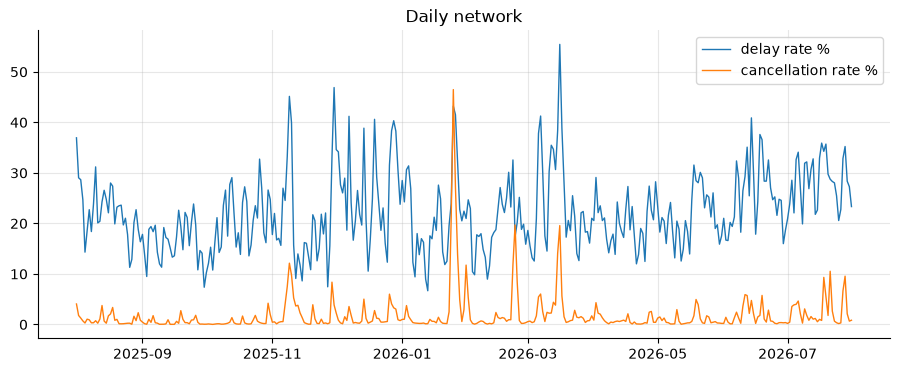

,flight_date,arr_delay_rate,cancellation_rate
177,2026-01-25,0.43210,0.46485
178,2026-01-26,0.41502,0.27120
176,2026-01-24,0.23929,0.21063
206,2026-02-23,0.17343,0.19684
227,2026-03-16,0.55430,0.19572
226,2026-03-15,0.38367,0.14068
179,2026-01-27,0.32012,0.13860
100,2025-11-09,0.45142,0.12132


In [10]:
n = q('SELECT flight_date, arr_delay_rate, cancellation_rate FROM marts.daily_network ORDER BY 1')
fig, ax = plt.subplots(); ax.plot(n.flight_date, 100*n.arr_delay_rate, lw=1, label='delay rate %')
ax.plot(n.flight_date, 100*n.cancellation_rate, lw=1, label='cancellation rate %'); ax.legend(); plt.title('Daily network'); plt.show()
n.sort_values('cancellation_rate', ascending=False).head(8)

A handful of days carry most cancellations (late January 2026 stands out). These spikes motivate the anomaly detector and explain why schedule-time cancellation models are weak.